# Notion-Zotero Analysis

Full pipeline: load canonical bundles → build summary tables → clean → explore.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import ast

from notion_zotero.analysis import (
    load_canonical_records,
    build_summary_dataframes,
    clean_table,
    run_analysis,
    is_accepted,
    task_label_fn,
)
from notion_zotero.analysis.original_db_summary import (
    TYPO_FIXES,
    GENERIC_VALUE_MAP,
    SEARCH_STRATEGY_COLUMNS,
)

from notion_zotero.analysis.table_normalization import (
    normalize_task_tables,
    build_task_value_count_table,
)
from notion_zotero.analysis.paper_tables import build_paper_summary_dataframes
from notion_zotero.analysis.visualization import (
    STYLE_COLORS,
    build_multivalue_trend,
    plot_multivalue_facets,
    plot_multivalue_trend,
    set_infographic_seaborn_style,
)

from notion_zotero.schemas.domain_packs.education_learning_analytics import (
    DATA_SOURCE_COLUMN_CANDIDATES,
    DATA_SOURCE_ALIAS_PATTERNS,
    DATA_SOURCE_MISSING_VALUES,
)

accepted_only = True  # Set to True to analyze only accepted papers, False to include all

# Load from live pulled data
pulled_dir = Path("data/pulled/notion/learning_analytics_review")
if not pulled_dir.exists() or not any(pulled_dir.glob("*.canonical.json")):
    raise FileNotFoundError(
        f"No pulled data found in {pulled_dir}. "
        "Run: notion-zotero pull-notion"
    )

bundles = load_canonical_records(str(pulled_dir))
print(f"Loaded {len(bundles)} bundles from {pulled_dir}")

Loaded 442 bundles from data\pulled\notion\learning_analytics_review


In [2]:
# Reusable project visualization style.
# Full helper definitions live in notion_zotero.analysis.visualization.
set_infographic_seaborn_style()


In [3]:
# --- Cell 2: Inspect loaded bundles ---
print(f"Loaded {len(bundles)} canonical bundles")

if bundles:
    sample = bundles[0]
    refs = sample.get("references", [])
    if refs:
        r = refs[0]
        print(f"Sample: {r.get("title", "(no title)")} ({r.get("year", "?")})")

Loaded 442 canonical bundles
Sample: Contrastive Personalized Exercise Recommendation With Reinforcement Learning (2024)


In [4]:
# --- Cell 3: Build summary tables (accepted papers only) ---
if accepted_only is True:
    accepted_bundles = [b for b in bundles if is_accepted(b)]
    print(f"Accepted: {len(accepted_bundles)} / {len(bundles)} total bundles")

else:
    accepted_bundles = bundles
    print(f"Including all bundles (accepted + excluded): {len(accepted_bundles)} total bundles")

dfs = build_summary_dataframes(accepted_bundles, task_label_fn=task_label_fn)
for name, df in dfs.items():
    print(f"  {name}: {len(df)} rows x {len(df.columns)} cols")
dfs.get("Reading List")

Accepted: 285 / 442 total bundles
  Reading List: 285 rows x 36 cols
  REC: 44 rows x 17 cols
  DESC: 79 rows x 20 cols
  PRED: 190 rows x 19 cols
  KT: 63 rows x 20 cols


,id,title,authors,year,journal,doi,url,zotero_key,abstract,item_type,...,Limitations,Completed,Keywords/Type,Learner Population,Learner Representation,Course-Agnostic Approach,Deployed/ Deployable,Work Nature,page_id,Motive For Exclusion
0,003e69cb-f908-470d-bab2-c26eed3c63d3,Contrastive Personalized Exercise Recommendati...,[Wu et al.],2024,IEEE Transactions on Learning Technologies,,,,,,...,False,2025-03-14T18:04:00.000+00:00,"[Contrastive Learning, Knowledge Tracing, Q-Le...",Intelligent Tutoring System,[Dynamic],True,Deployed by Instructor,"[Public Dataset, Tested on New Students]",003e69cb-f908-470d-bab2-c26eed3c63d3,
1,00f24000-f241-438b-a023-d872bc2b59e6,Using Clickstream Data Mining Techniques to Un...,[Rodriguez et al.],2021,LAK,,,,,,...,False,2024-08-02T09:00:00.000+01:00,"[Clickstream Data Mining, STEM, Online Learnin...",Higher Education,[Static Aggregate],False,Prototype,[Backtested with data from Previous Students],00f24000-f241-438b-a023-d872bc2b59e6,
2,02eedcf7-bc5a-406e-ba94-01f7e39a25cd,Enhancing educational evaluation through predi...,[Xuan Lam et al],2024,Computers & Education: Artificial Intelligence,,,,,,...,True,2024-05-27T22:00:00.000+01:00,"[Data Science Applications in Education, Educa...",Higher Education,[Static Aggregate],True,Prototype,[Backtested with data from Previous Students],02eedcf7-bc5a-406e-ba94-01f7e39a25cd,
3,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Implementing AutoML in Educational Data Mining...,[Tsiakmaki et al.],2019,Applied Sciences,,,,,,...,False,2024-07-31T09:00:00.000+01:00,"[Automatic Machine Learning, Educational Data ...",Higher Education,[Static Aggregate],False,Prototype,[Backtested with data from Previous Students],02fef9f2-c5c2-47ee-a111-eb7788556c5e,
4,033342f8-04d7-4a83-b56e-7d8b056b12e2,A Robust Machine Learning Technique to Predict...,[Liao et al.],2019,ACM Transactions on Computing Education,,,,,,...,False,2024-07-31T09:00:00.000+01:00,"[Computing Education, Computer Science Educati...",Higher Education,[Sequence],False,Prototype,[Backtested with data from Previous Students],033342f8-04d7-4a83-b56e-7d8b056b12e2,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,fbabc039-d7a3-4330-88f4-1038cbba4145,Developing early warning systems to predict st...,[Hu et al.],2014,Computers in Human Behavior,,,,,,...,True,2024-08-26T20:00:00.000+01:00,"[Learning management systems, E-Learning, Earl...",Higher Education,[Static Aggregate],False,Prototype,[Backtested with data from Previous Students],fbabc039-d7a3-4330-88f4-1038cbba4145,
281,fbe0c99f-8e17-471c-a700-6586193253e2,Early-predicting dropout of university student...,[Cannistrà et al.],2022,Studies in Higher Education,,,,,,...,True,2024-08-04T09:00:00.000+01:00,"[Learning Analytics, Early Warning Systems, St...",Higher Education (Not Course Related),[Static Aggregate],False,Prototype,[Backtested with data from Previous Students],fbe0c99f-8e17-471c-a700-6586193253e2,
282,fd6153cf-0a1c-4664-9a99-74f4264d7d8e,A data-driven approach to predict first-year s...,[Gil et al.],2021,Education and Information Technologies,,,,,,...,True,2024-08-02T09:00:00.000+01:00,"[Academic Success, Data Mining, Higher Educati...",Higher Education (Not Course Related),[Static Aggregate],False,Prototype,[Backtested with data from Previous Students],fd6153cf-0a1c-4664-9a99-74f4264d7d8e,
283,fe76c297-6135-4a41-b537-d3637a4ac389,What are the most important predictors of comp...,[Hao et al.],2016,Computers in Human Behavior,,,,,,...,True,2024-10-09T13:00:00.000+01:00,"[Online Academic Help-Seeking, Important Predi...",Higher Education,[Static Aggregate],True,Out of Scope,[Backtested with data from Previous Students],fe76c297-6135-4a41-b537-d3637a4ac389,


In [5]:
# --- Cell 4: Clean tables ---
# MY_TYPO_FIXES and MY_VALUE_MAP extend the package defaults with notebook-specific overrides.
MY_TYPO_FIXES = {
    **TYPO_FIXES,
    r"\bMAchine\b": "Machine",
    r"Fiiltering": "Filtering",
    r"Exerrcise": "Exercise",
}
MY_VALUE_MAP = {**GENERIC_VALUE_MAP, "n/a": "Not Applicable", "none": "Not Applicable"}

cleaned_dfs = {}
_clean_logs = {}
for name, df in dfs.items():
    cleaned, log = clean_table(
        df,
        typo_fixes=MY_TYPO_FIXES,
        value_map=MY_VALUE_MAP,
        search_strategy_columns=SEARCH_STRATEGY_COLUMNS,
    )
    cleaned_dfs[name] = cleaned
    _clean_logs[name] = log
    print(f"  {name}: {log['text_updates']} cell(s) normalised")

  Reading List: 379 cell(s) normalised
  REC: 89 cell(s) normalised
  DESC: 263 cell(s) normalised
  PRED: 392 cell(s) normalised
  KT: 178 cell(s) normalised


In [6]:
norm_log = {
    name: {
        "rows_before": len(dfs[name]),
        "rows_after": len(cleaned_dfs[name]),
        "text_updates": _clean_logs[name]["text_updates"],
        "search_strategy_updates": _clean_logs[name].get("search_strategy_updates", 0),
    }
    for name in dfs
}
pd.DataFrame(norm_log).T

,rows_before,rows_after,text_updates,search_strategy_updates
Reading List,285,285,379,284
REC,44,44,89,0
DESC,79,79,263,0
PRED,190,190,392,0
KT,63,63,178,0


In [7]:
rl = cleaned_dfs.get("Reading List", pd.DataFrame())
if not rl.empty and "year" in rl.columns:
    display(rl["year"].value_counts().sort_index())
if not rl.empty and "journal" in rl.columns:
    display(rl["journal"].dropna().replace("", pd.NA).dropna().value_counts().head(10))
if not rl.empty and "database" in rl.columns:
    display(rl["database"].dropna().replace("", pd.NA).dropna().value_counts().head(10))
if not rl.empty and "journal_quartile" in rl.columns:
    display(rl["journal_quartile"].dropna().replace("", pd.NA).dropna().value_counts())
for name, df in cleaned_dfs.items():
    if name != "Reading List" and not df.empty:
        print(f"\n{name} ({len(df)} rows):")
        display(df.head(3))

year
2012     2
2013     5
2014     4
2015    10
2016     7
2017    21
2018    18
2019    18
2020    38
2021    34
2022    29
2023    39
2024    45
2025    13
2026     2
Name: count, dtype: int64

journal
LAK                                           40
IEEE Transactions on Learning Technologies    17
Computers & Education                         16
ArXiv                                         10
Applied Sciences                               9
Internet and Higher Education                  9
EDM                                            9
Knowledge-Based Systems                        8
IEEE Access                                    8
Computers in Human Behavior                    8
Name: count, dtype: int64

database
Google Scholar         195
ACM Digital Library     38
ISI Web of Science      27
IEEE Xplore             14
Scopus                  10
IEEE XPlore              1
Name: count, dtype: int64

journal_quartile
Q1 Journal              125
Conference               85
Q2 Journal               42
Q3+ Journal              18
ArXiv                    10
Book Chapter              4
Unreferenced Journal      1
Name: count, dtype: int64


REC (44 rows):


...

,Task,Context,Teaching Method,Students,Courses,Data sources,Theoretical Grounding,Features,Preprocessing Details,Models,Performance Metric: Best Model,Groups Created,Cluster Description,Implications,Comments,Limitations,source_page_id,source_title,schema_name,Thereotical Model
0,Clustering,Higher Education,E-Learning,312 students,1 Preparation for General Chemistry Course,"LMS logs, Student Characteristics",None Specified,"[First Generation, Proportion of Video Visits,...",Clickstream logs are converted into the 2 SRL ...,k-Means,"VVI: -1428.62 - 4 clusters, VVE: -1433.36 - 4 ...",4,"Group 1: Early Planning, \n\nGroup 2: Planning...",Students in early planning received the highes...,Authors use ANOVAs to compare differences betw...,k-Means only\n\nLimited Access to LMS data,00f24000-f241-438b-a023-d872bc2b59e6,Using Clickstream Data Mining Techniques to Un...,descriptive_analysis,
1,Regression,Higher Education,E-Learning,312 students,1 Preparation for General Chemistry Course,"LMS logs, Student Characteristics",None Specified,"[First Generation, Proportion of Video Visits,...",Clickstream logs are converted into the 2 SRL ...,Step-Wise Regression,{RSquared: 0.336 - Model 7},-,First-generation status had a significant nega...,Students in early planning received the highes...,Authors use ANOVAs to compare differences betw...,Unexplained reasons for why First-Generation S...,00f24000-f241-438b-a023-d872bc2b59e6,Using Clickstream Data Mining Techniques to Un...,descriptive_analysis,
2,Clustering,Higher Education,Not Applicable,1100 undergraduate students,Courses in the CS department at a Greek Univer...,Student Information System,None Specified,"[GPA, Specialization Field, Capstone Project G...",Preprocessing involves 3 main steps:\n\n- Remo...,k-Means,Sum of Square Residuals,3,Cluster 1: Composed by close to 50% of student...,Clustering students before creating a classifi...,Clustering is used ass part of a more overarch...,- System does not perform early prediction\n\n...,060989c9-da7d-41d8-9ad2-04ebad13c871,A two-phase Machine learning approach for pred...,descriptive_analysis,



PRED (190 rows):


,Task,Context,Teaching Method,Student Performance Definition,Target,Students,Courses,Data sources,Features,Moment of Prediction,Preprocessing Details,Models,Assessment Strategy,Performance Metric: Best Model,Comments,Limitations,source_page_id,source_title,schema_name
0,Classification,Higher Education,E-Learning,Grade Range,"A, B, C and F",253 second and third year undergraduate students,"5 Classes in Web Design, Web Technologies and ...","LMS logs, Student Demographics, Academic Backg...","[Consistency, Following, Review Score, Attenda...",End of Course,Data was standardized and nans were imputted u...,"kNN, Random Forest, Logistic Regression, SVM, ...",Holdout Method (80/20),"{Accuracy: 0.826 - Stacking, Precision: 0.805 ...",Authors do a standard classification problem o...,Models overfit.\n\nPrediction of average grade...,02eedcf7-bc5a-406e-ba94-01f7e39a25cd,Enhancing educational evaluation through predi...,prediction_modeling
1,Classification,Higher Education,Blended Learning,End of Course Performance,Pass (>=5) vs Fail (<5),591 students,3 compulsory university courses: Physical Chem...,"LMS logs, Student characteristics, Learner grades",[Gender; forum views; page views; resource vie...,Monthly early prediction during semester; 6 cu...,Custom Moodle plugin exported cumulative month...,"Naïve Bayes, Random Forest, Bagging, PART, SMO...",10-fold Cross-Validation,Best AutoML results:\n{Accuracy: 0.9302 - Auto...,Main contribution is showing that AutoML impro...,Single institution and only 3 courses. Results...,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Implementing AutoML in Educational Data Mining...,prediction_modeling
2,Regression,Higher Education,Blended Learning,End of Course Performance,inal grade (0–10),591 students,3 compulsory university courses: Physical Chem...,"LMS logs, Student characteristics, Learner grades",[Gender; forum views; page views; resource vie...,Monthly early prediction during semester; 6 cu...,Custom Moodle plugin exported cumulative month...,"Random Forest, M5Rules, Bagging, SMOreg, IBk-5...",10-fold Cross-Validation,Best AutoML results:\n{MAE = 1.0402 – M5P for ...,AutoML improved regression performance in all ...,Same limitations as above; results are course-...,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Implementing AutoML in Educational Data Mining...,prediction_modeling



KT (63 rows):


,Task,Context,Teaching Method,Student Performance Definition,Target,Students,Courses,Data sources,Features,Flaw of Previous Models,Novelty of Model,Preprocessing Details,Models,Assessment Strategy,Performance Metric: Best Model,Comments,Limitations,source_page_id,source_title,schema_name
0,Classification,Intelligent Tutoring System,E-Learning,Predicting the Option Selected by Student in M...,Options Selected,10499 learners,Mathematics & German in Lernnavi,"Answer Sequences, Questions, Topic Taxonomies","[User Generated Transactions, Questions (and O...",Most approaches that are SoTA usually focus on...,The proposed model uses LLMs to understand con...,Users are first organized into learning sessio...,"MCQStudentBertCat, MCQStudentBertSum",Holdout Method,{MCC: 0.579 - MCQStudentBertCat with Mistral E...,Authors compare the 2 different models: MCQStu...,Limited interpretability of embedding-based mo...,17c20953-fb22-4346-b8e5-938e56b2be51,Student Answer Forecasting: Transformer-Driven...,sequence_tracing
1,Regression,Intelligent Tutoring System,,Score in Exercise,"Continuous score [0,1]","1825 Algebra05&06 learners,\n1112 Bridge Algeb...","Algebra, ASSISTments",Answer Sequences and Scores obtained,[Sequences of Scores for Previous Questions in...,Most of the current state-of-the-art KT models...,The addition of fuzziness to BKT allows for th...,"In essence, Fuzzy BKT and T2FBKT takes the per...","BKT, DKT, DKVMN, DKT+, DKT_DSC, DeepIRT, SAKT,...",5-Fold Cross-Validation,"{Average MAE Rank: 1.47 - T2FBKT, Average RMSE...",Authors explore the idea of introducing fuzine...,This fuzzy approach is exclusively applied to ...,18b4750c-f3ba-8001-846c-eddab66ea586,Fuzzy Bayesian Knowledge Tracing,sequence_tracing
2,Classification,MOOC,,Succeeding in Subsequent Programming Task,Succeed (1) vs Fail (0),"328128 HOC4 learners, 152869 HOC18 learners","HOC4, HOC8","Perfect Solution for each task, Intermediate l...","[pathLength, currentPerf, AIScore]","BKT, DKT or Additive Factor Model (AFM) strugg...",Authors present an Approaching Index - a measu...,Paths that do not lead to a solution have been...,"LR+pathLength, LR+currentPerf, PoissonPath, DK...",Holdout Method,HOC4 to HOC5\n{Accuracy: 0.95958 - LR+currentP...,"In programming tasks, reaching a solution can ...",Limited number of tasks for evaluation.\n\nPro...,18b4750c-f3ba-8005-9ff0-d7886becd1e4,Knowledge Tracing Within Single Programming Pr...,sequence_tracing


## Paper Analysis Outputs

1. Check and count Unique Search Terms

In [8]:
# #get value_counts of unique search terms from Reading List
# if "Reading List" in cleaned_dfs:
#     search_terms = cleaned_dfs["Reading List"]["search_terms"].dropna().replace("", pd.NA).dropna()
#     print("\nUnique search terms and their counts:")
#     display(search_terms.value_counts())

2. Get Rejection Status - may also need some typo correction and text normalization, similar to Search Terms Column

In [9]:
#group by Status and Motive For Exclusion and count
reading_list = cleaned_dfs.get("Reading List", pd.DataFrame())
if not reading_list.empty and "Status" in reading_list.columns and "Motive For Exclusion" in reading_list.columns:
    exclusion_counts = (
        reading_list.groupby(["Status", "Motive For Exclusion"])
        .size()
        .reset_index(name="Count")
    )
    print("\nCounts by Status and Motive For Exclusion:")
    display(exclusion_counts)


Counts by Status and Motive For Exclusion:


,Status,Motive For Exclusion,Count
0,Accepted For Descriptive Modelling,,56
1,Accepted For Descriptive Modelling,Comparison & Outcome,1
2,Accepted For Knowledge Tracing,,53
3,Accepted For Knowledge Tracing,Population,1
4,Accepted For Performance Prediction Task,,132
5,Accepted For Performance Prediction Task,Comparison,1
6,Accepted For Performance Prediction Task,Quality,1
7,Accepted For Recommender Systems,,40


3. Figure 2

Evolution of Learner Representation over the Years (only consider top 3: Static Aggregate, Dynamic and Sequence). Line and facet grid per task

In [10]:
#check Learner Representation column for unique values and counts
if not reading_list.empty and "Learner Representation" in reading_list.columns:
    learner_representation_counts = (
        reading_list["Learner Representation"]
        .dropna()
        .replace("", pd.NA)
        .dropna()
        .value_counts()
        .reset_index(name="Count")
    )
    print("\nLearner Representation counts:")
    display(learner_representation_counts)


Learner Representation counts:


,Learner Representation,Count
0,[Static Aggregate],146
1,[Sequence],86
2,[Dynamic],29
3,"[Sequence, Dynamic]",8
4,"[Static Aggregate, Sequence]",5
5,"[Dynamic, Sequence]",3
6,[Not Applicable],3
7,"[Dynamic, Static Aggregate]",1
8,"[Sequence, Static Aggregate]",1


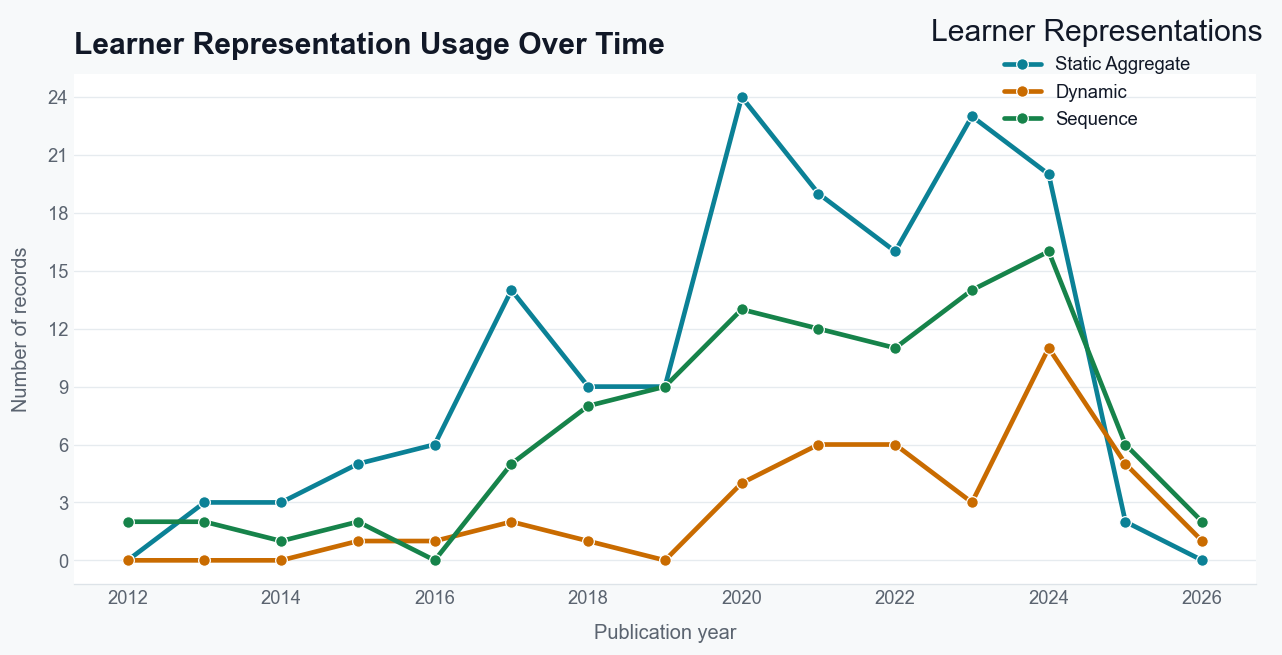

In [11]:
TOP_REPRESENTATIONS = ["Static Aggregate", "Dynamic", "Sequence"]
REPRESENTATION_PALETTE = {
    "Static Aggregate": STYLE_COLORS["teal"],
    "Dynamic": STYLE_COLORS["orange"],
    "Sequence": STYLE_COLORS["green"],
}

reading_list = cleaned_dfs["Reading List"].copy()

chart1_df = build_multivalue_trend(
    reading_list,
    value_col="Learner Representation",
    selected_values=TOP_REPRESENTATIONS,
)

fig, ax = plot_multivalue_trend(
    chart1_df,
    selected_values=TOP_REPRESENTATIONS,
    palette=REPRESENTATION_PALETTE,
    title="Learner Representation Usage Over Time",
    legend_title="Learner Representations",
)
plt.show()


Figure 3: Same as Figure 2 but divided per task

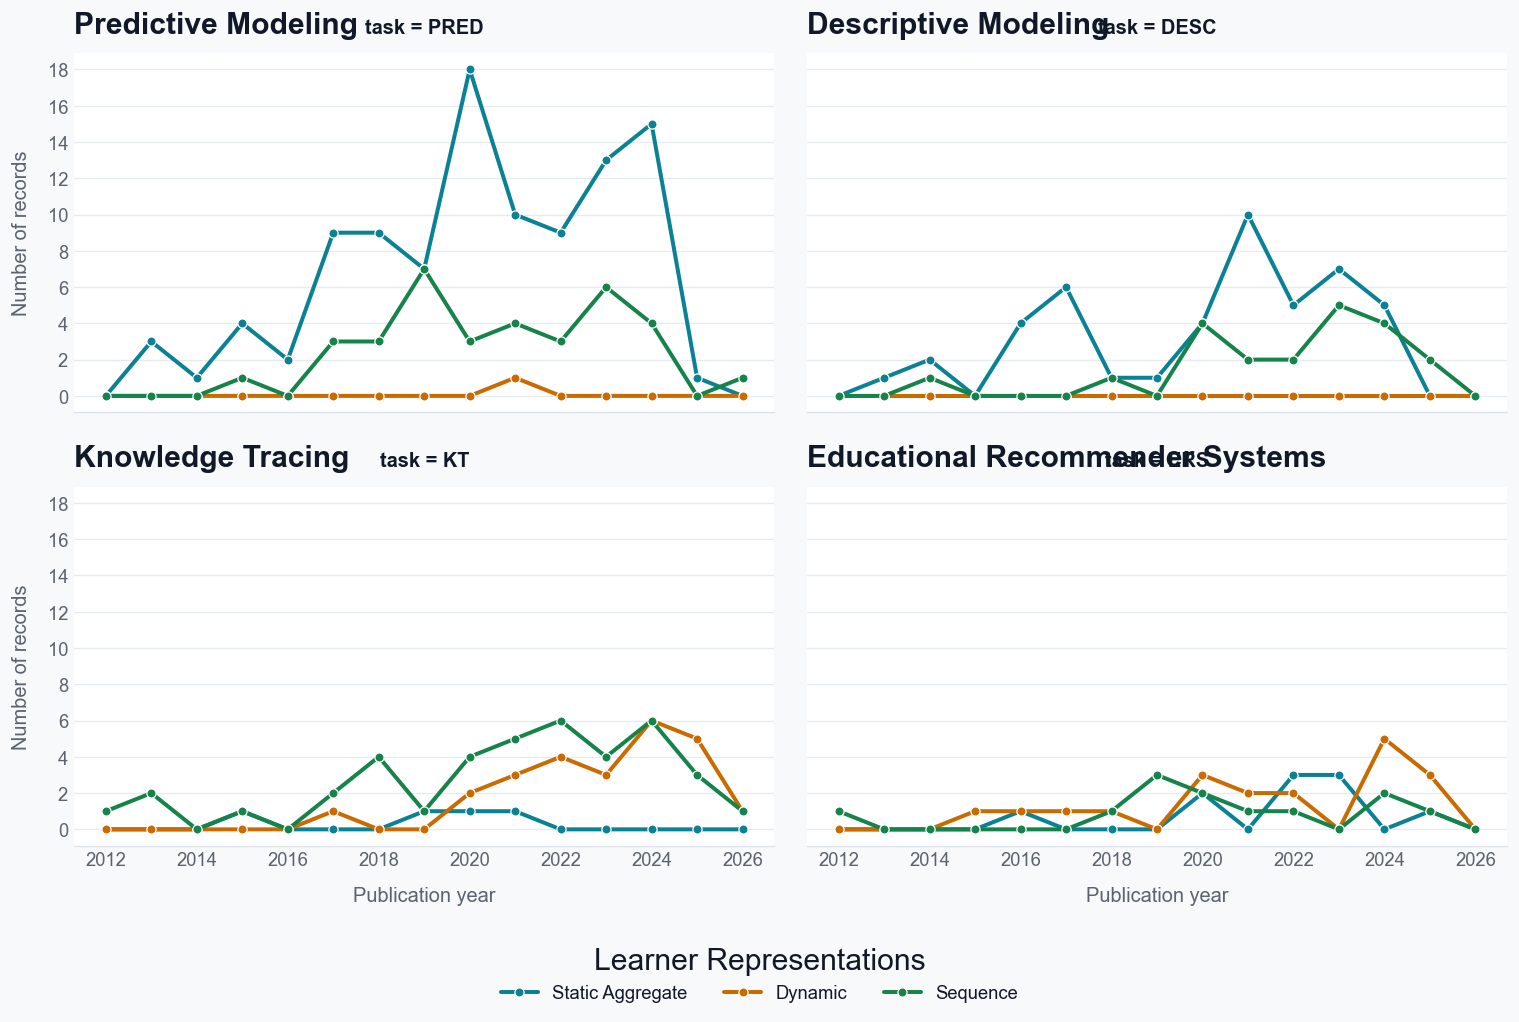

In [12]:
TOP_REPRESENTATIONS = ["Static Aggregate", "Dynamic", "Sequence"]
TASK_ORDER = ["PRED", "DESC", "KT", "ERS"]
TASK_TITLE_MAP = {
    "PRED": "Predictive Modeling",
    "DESC": "Descriptive Modeling",
    "KT": "Knowledge Tracing",
    "ERS": "Educational Recommender Systems",
}
TASK_STATUS_PATTERNS = {
    "PRED": [r"pred", r"predictive", r"performance prediction"],
    "DESC": [r"desc", r"descriptive"],
    "KT": [r"kt", r"knowledge tracing"],
    "ERS": [r"ers", r"recommender", r"recsys"],
}
REPRESENTATION_PALETTE = {
    "Static Aggregate": STYLE_COLORS["teal"],
    "Dynamic": STYLE_COLORS["orange"],
    "Sequence": STYLE_COLORS["green"],
}

reading_list = cleaned_dfs["Reading List"].copy()

chart2_df = build_multivalue_trend(
    reading_list,
    value_col="Learner Representation",
    selected_values=TOP_REPRESENTATIONS,
    group_source_cols=["Status", "Status_1"],
    group_patterns=TASK_STATUS_PATTERNS,
    group_order=TASK_ORDER,
    group_col="task",
    required_group_prefix="Accepted for",
)

g = plot_multivalue_facets(
    chart2_df,
    selected_values=TOP_REPRESENTATIONS,
    group_col="task",
    group_order=TASK_ORDER,
    group_title_map=TASK_TITLE_MAP,
    palette=REPRESENTATION_PALETTE,
    legend_title="Learner Representations",
)
plt.show()


In [13]:
TASK_TABLES = {
    "PRED": "PRED",
    "DESC": "DESC",
    "KT": "KT",
    "REC": "ERS",   # current internal package label -> presentation label
}

TASK_ORDER = ["PRED", "DESC", "KT", "ERS"]

normalized_task_tables, data_source_long, data_source_audit = normalize_task_tables(
    dfs=cleaned_dfs,
    task_tables=TASK_TABLES,
    value_column_candidates=DATA_SOURCE_COLUMN_CANDIDATES,
    alias_patterns=DATA_SOURCE_ALIAS_PATTERNS,
    value_col="data_source",
    keep_unmatched=True,
    missing_values=DATA_SOURCE_MISSING_VALUES,
)

data_source_table = build_task_value_count_table(
    data_source_long,
    task_order=TASK_ORDER,
    value_col="data_source",
    label_col="Data source",
    total_col="Total",
)

display(data_source_table)

task,Data source,PRED,DESC,KT,ERS,Total
0,LMS/VLE/MOOC logs,85,48,26,18,177
1,Assessment/performance records,59,26,6,7,98
2,Student demographics/characteristics,49,8,0,6,63
3,Exercise/question/Assignment metadata,1,1,35,6,43
4,Questionnaire/ Interview data,7,20,1,8,36
5,Administrative/SIS records,20,4,0,9,33
6,Academic background records,24,2,0,3,29
7,Course/content metadata,9,3,1,11,24
8,Exercise/question interactions,1,0,17,5,23
9,Question/Answer Sequences,0,0,21,2,23


In [14]:
# --- Build camera-ready paper summary tables (one row per paper per task) ---
paper_task_tables, paper_task_audit = build_paper_summary_dataframes(
    cleaned_dfs,
    task_tables=TASK_TABLES,
    include_title=True,
)

for task, table in paper_task_tables.items():
    print(f"{task}: {len(table)} paper row(s) x {len(table.columns)} columns")
    display(table.head(10))

if not paper_task_audit.empty:
    print(f"Paper-table audit rows: {len(paper_task_audit)}")
    display(paper_task_audit.head(30))

PRED: 181 paper row(s) x 14 columns


,Study,Paper title,Learner representation,Work nature,Context,Teaching modality,Data sources,Sample / setting,Prediction task type,Prediction target / timing,Algorithms / models,Assessment strategy,Results,Limitations
0,Romero et al. (2013),Predicting students’ final performance from pa...,Static Aggregate,Backtested with data from Previous Students,Higher Education,E-Learning; Blended Learning; Face-to-Face Lea...,LMS/VLE/MOOC logs; Student demographics/charac...,114 - 1 Computer Science Fundamentals course,Classification,Pass vs Fail in the course - Fail vs Pass - Co...,DTNB; JRip; NNge; Ridor; ADTree; J48; Random F...,K-Fold Cross-Validation; Stratified Cross-Vali...,Accuracy=0.824 (SMO & NB); F1=0.822 (NB); Accu...,Limited preprocessing endeavours. Small sample...
1,Romero et al. (2013),Predicting students’ final performance from pa...,Static Aggregate,Backtested with data from Previous Students,Higher Education,E-Learning; Blended Learning; Face-to-Face Lea...,LMS/VLE/MOOC logs; Student demographics/charac...,114 - 1 Computer Science Fundamentals course,Clustering,Pass vs Fail in the course - Fail vs Pass - Co...,Expectation-Maximization; Hierarchical Cluster...,K-Fold Cross-Validation; Stratified Cross-Vali...,Accuracy=0.807 (EM); F1=0.755 (EM); Accuracy=0...,Limited preprocessing endeavours. Small sample...
2,Romero et al. (2013),Web usage mining for predicting final marks of...,Static Aggregate,Public Dataset,Higher Education,E-Learning,LMS/VLE/MOOC logs,438 - 7 Engineering Courses,Classification,Predict the student's final grade - End of Course,ADLinear; PolQuadraticLMS; Kernel; k-Nearest N...,K-Fold Cross-Validation; Stratified Cross-Vali...,Accuracy=0.6599 (GAP),Limited pre-processing techniques used. No tes...
3,Romero et al. (2013),Web usage mining for predicting final marks of...,Static Aggregate,Public Dataset,Higher Education,E-Learning,LMS/VLE/MOOC logs,438 - 7 Engineering Courses,Classification,Predict the student's final grade - End of Course,ADLinear; PolQuadraticLMS; Kernel; k-Nearest N...,K-Fold Cross-Validation; Stratified Cross-Vali...,Accuracy=0.6586 (CART on Discretized Data); om...,Limited pre-processing techniques used. No tes...
4,Wolff et al. (2013),Improving retention: predicting at-risk studen...,Static Aggregate,Public Dataset,Higher Education,E-Learning,LMS/VLE/MOOC logs; Assessment/performance reco...,4397 - Module A 1292 - Module B 2012 - Module ...,Classification,"Being successful and, for some reason, achievi...",C4.5; Support Vector Machine,K-Fold Cross-Validation,"{Precision: [0.77, 0.98] - C4.5, Recall: [0.5,...",Limited number of algorithms to use. Features ...
5,Wolff et al. (2013),Improving retention: predicting at-risk studen...,Static Aggregate,Public Dataset,Higher Education,E-Learning,LMS/VLE/MOOC logs; Assessment/performance reco...,4397 - Module A 1292 - Module B 2012 - Module ...,Classification,Passing or Failing the Module - Fail (0) vs Pa...,C4.5; Support Vector Machine,K-Fold Cross-Validation,Precision=0.74 (C4.5 with 4 TMA and no Demogra...,Limited number of algorithms to use. Features ...
6,Hu et al. (2014),Developing early warning systems to predict st...,Static Aggregate,Backtested with data from Previous Students,Higher Education,E-Learning,LMS/VLE/MOOC logs,300 - 1 Information Literacy and Information E...,Classification,"Average of midterm and final exam ≥ 60: Pass, ...",C4.5; Decision Tree; Logistic Regression; AdaB...,K-Fold Cross-Validation,Accuracy=0.972 (AdaBoost+C4.5 & AdaBoost+CART)...,Small dataset featuring data from a single onl...
7,Brooks et al. (2015),A time series interaction analysis method for ...,Sequence,Backtested with data from Previous Students,MOOC,E-Learning,LMS/VLE/MOOC logs,33013 - Literature 77900 - Internet 104250 - P...,Classification,Achieving a Passing Grade in MOOC Summative Ev...,J48,Holdout,Keiss kappa=0.73 (Networks); Accuracy=0.9899 (...,No feature selection was performed. Does not u...
8,Kostopoulos et al. (2015),Estimating student

DESC: 78 paper row(s) x 14 columns


,Study,Paper title,Learner representation,Work nature,Context,Teaching modality,Data sources,Sample / setting,Analytic task,Algorithms / models,Results / patterns,Theoretical grounding,Main result / implication,Limitations
0,Wolff et al. (2013),Improving retention: predicting at-risk studen...,Static Aggregate,Public Dataset,Higher Education,E-Learning,LMS/VLE/MOOC logs; Assessment/performance reco...,4397 - Module A 1292 - Module B 2012 - Module ...,Association Rule Mining,GUHA (70% Confidence and 0.001 Support),"GUHA was able to identify, with high degree of...",,Difficulty in drawing conclusions about learne...,Limited number of algorithms to use. Features ...
1,Agudo-Peregrina et al. (2014),Can we predict success from log data in VLEs? ...,Static Aggregate,Backtested with data from Previous Students,Higher Education,E-Learning; Traditional Setting,LMS/VLE/MOOC logs,138 Online students 218 Face-to-face students ...,Regression,Linear Regression,"Not clustering, but authors distinguish betwee...",Moore’s Typology of Interaction Types,It is necessary to study moderating effects of...,Approach only reveals to be effective for onli...
2,Bannert et al. (2014),Process mining techniques for analysing patter...,Sequence,Tested on New Students,Higher Education,Think-Aloud Method,Wearable Devices/ Sensors; LMS/VLE/MOOC logs,38 - Individualized Sessions,Process Mining,Fuzzy Miner,2; Model is capable of explaining 40% of the s...,Self-Regulated Learning,Process Mining should not be used directly for...,Small sample size Lack of standardized routine...
3,Castillo-Merino & Serradell-López (2014),An analysis of the determinants of students’ p...,Static Aggregate,Backtested with data from Previous Students,Higher Education,E-Learning,Questionnaire/ Interview data,127 - 3 courses: Introduction to Financial Acc...,Factor Analysis,Structural Equation Modeling,Motivation is the most important predictor of ...,Theoretical Model Proposed by Authors,SEM is a good model to explain predictors of s...,Questionnaire data Courses used are teached in...
4,Brouwer et al. (2016),The impact of social capital on self-efficacy ...,Static Aggregate,Tested on New Students,Higher Education,Collaborative Learning,Survey data; Academic background records,364 first-year students - All courses in the B...,Clustering,Multi-Level Regression Analysis,3; Low Achievers Average Achievers High achiev...,Self-Regulated Learning,Peer and Faculty capital contribute to explain...,Study focuses only on access to social capital...
5,Cerezo et al. (2016),Students' LMS interaction patterns and their r...,Static Aggregate,Backtested with data from Previous Students,Higher Education,E-Learning,LMS/VLE/MOOC logs; Assessment/performance records,140 students - 1 module as part of a eTRAL course,Clustering,Expectation-Maximization; k-Means,4; Pairwise similarities between Clusters 1 an...,,Understanding the characteristics of different...,Does not explain why students with different e...
6,Hao et al. (2016),What are the most important predictors of comp...,Static Aggregate,Backtested with data from Previous Students,Higher Education,Blended Learning,Survey data; Assessment/performance records,203 students - 162 in introductory course 42 i...,Classification,Linear Regression,"2; Expert students would, on average, report t...",,Academically challenged and novice students wo...,Data is only based on self-reports. Small samp...
7,Hao et al. (2016),What are the most important predictors of comp...,Static Aggregate,Backtested with data from Previous Students,Higher Education,Blended Learning,Survey data; Assessment/performance records,203 students - 162 in introductory course 42 i...,Classification,Linear Regression,"2; Expert students would, on average, report t...",,Academically challenged and novice students wo...,Data is only based on self-reports. Small samp...
8,Hao et al. (2016),What are the most important predictors of comp...,Static Aggregate,Backtested with data from Previous Stude

KT: 63 paper row(s) x 15 columns


,Study,Paper title,Learner representation,Work nature,Context,Teaching modality,Data sources,Sample / setting,KT target,Algorithms / models,Assessment strategy,Results,Prior-model limitations,New contribution,Study limitations
0,Pardos et al. (2012),The Sum is Greater than the Parts: Ensembling ...,Sequence,Public Dataset,Intelligent Tutoring System,,Question/Answer Sequences; Exercise/question/A...,5422 learners - Assistments,Predict whether the student will answer the ne...,En-NeuralNet; En-RandomForest; En-AdaBoost-J48...,K-Fold Cross-Validation,AUC=0.7719 (En-NeuralNet); AUC=0.7693 (En-Neur...,Models have generally been proposed in isolation.,Attempts to used Ensemble Logic to combine the...,Amount of data required for the models to be e...
1,Pardos et al. (2013),Adapting Bayesian Knowledge Tracing to a Massi...,Sequence,Backtested with data from Previous Students,MOOC,,LMS/VLE/MOOC logs,2000 EdX learners - Course 6.002X: Circuit Design,Predict whether the student will answer the ne...,BKT,K-Fold Cross-Validation,AUC=0; AUC=0.6814 (BKT-IDEM-Count),In intelligent tutoring systems there is a con...,The authors’ implementation of BKT includes a ...,Authors only publish results using AUC score. ...
2,Yudelson et al. (2013),Individualized Bayesian Knowledge Tracing Models,Sequence,Public Dataset,Intelligent Tutoring System,,Exercise/question interactions,9353 learners - Algebra I and Bridge to Algebra,Predict whether the student will answer the ne...,BKT; BKT_L0; BKT_T; BKT_L0_T,K-Fold Cross-Validation,RMSE=0.34060 (BKT_L0_T→ Skill model B); Accura...,BKT models only consider a finite set of param...,BKT with student parameters uses negative log ...,Only BKT is explored. Limityed number of datas...
3,Brinton & Chiang (2015),MOOC performance prediction via clickstream da...,Static Aggregate,Backtested with data from Previous Students,MOOC,,LMS/VLE/MOOC logs,"5205 - 1 Networks: Friends, Money, and Bytes C...",Predict whether the student will answer the ne...,Naive; Biases; Matrix Factorization; k-Nearest...,K-Fold Cross-Validation,Accuracy=0.725 (VID-A); RMSE=0.428 (VID-N & VI...,Typical measures used in MOOC environments - i...,Authors look to use behavioral data to predict...,Data sparsity with small number of active user...
4,Piech et al. (2015),Deep Knowledge Tracing,Sequence,Public Dataset; Backtested with data from Prev...,MOOC,,Question/Answer Sequences; Exercise/question/A...,4000 simulated 47495 Khan Math 15931 Assistmen...,Predict whether the student will answer the ne...,Marginal; BKT; DKT,K-Fold Cross-Validation,AUC=0.75 (DKT); AUC=0.85 (DKT); AUC=0.86 (DKT),"BKT is based on Hiden Markov Models, where the...","RNNs use a continuous latent space, which (as ...",RNNs require a lot more data than an Hidden Ma...
5,Kaser et al. (2017),Dynamic Bayesian Networks for Student Modeling,Sequence,Public Dataset,Intelligent Tutoring System,,Question/Answer Sequences,"6043 Algebra learners, 7265 Dybuster learners,...",Predict whether the student will answer the ne...,DBNc1; DBNc2; DBNc3; DBNc4; BKTc; AFM; PFA,K-Fold Cross-Validation,RMSE=0.4378 (DBNc4); AUC=0.7026 (DBNc2); Relia...,BKT is unable to identify relationships betwee...,The authors embloy Dynamic Bayesian Networks t...,"Model does not include ability to forget, some..."
6,Zhang et al. (2017),Dynamic Key-Value Memory Networks for Knowledg...,Dynamic,Public Dataset,Intelligent Tutoring System,,Exercise/question interactions; Exercise/quest...,"4000 Synthetic learners, 4151 ASSISTments2009 ...",Predict whether the student will answer the ne...,BKT; MANN; DKT; DKVMN,Holdout,AUC=0.8273 (DKVMN); AUC=0.8157 (DKVMN); AUC=0....,BKT and DKT (the at the time state-of-the-art)...,Memory augmented Neural Networks are a foprm o...,Does not perform cross-Validation. Only takes ...
7,Zhang et al. (2017),Incorporating Rich Features into Deep Knowledg...,Sequence,Public Dataset,Intelligent Tutoring System,,Question/Answer Sequences; Exercise/question/A...,"3866 ASSISTments learners, 332 

ERS: 44 paper row(s) x 15 columns


,Study,Paper title,Learner representation,Work nature,Context,Teaching modality,Data sources,Sample / setting,Recommendation target,Recommender type,Recommendation output,Algorithms / models,Results,Limitations,Key implementation note
0,Xu et al. (2012),Personalized Learning Path Recommender Based o...,Sequence,Tested on New Students,Higher Education,E-Learning,In-Campus Behavioral Data,200 Computer Science students - 1 C Programmin...,Recommend courses or learning paths to students,Collaborative Filtering,Next Recommended Action,Collaborative Filtering; Graph Search,Learning Time=115.2; Average Grade=81.4; Knowl...,Only considers preferences from the most inter...,Users are initialized via the profiling via so...
1,Dascalu et al. (2015),A recommender agent based on learning styles f...,Dynamic,Tested on New Students,Higher Education,E-Learning,Administrative/SIS records,25 students - Not Applicable - students belong...,Learning Materials,Collaborative Filtering,Shortcuts: based on static information Suggest...,Collaborative Filtering,Satisfaction=12,- Results on accuracy of LS evaluation or Reco...,Learning Style is inferred from Questionnaire....
2,Santos & Boticario (2015),Practical guidelines for designing and evaluat...,,Tested on New Students,Educational Recommender Systems Guidelines,E-Learning,Questionnaire/ Interview data,125 educators 595 students - - 1 Introduction ...,Actions to take in platform.,Ontology-Based,Next Action to take on the LMS platform.,Ontology-Based Recommendation,Validated by Educators and Learners. Learning ...,Paper merely describes practical guidelines. N...,Learning Style Questionnaire Profile data; - N...
3,Tam et al. (2015),Enhancing Educational Data Mining Techniques o...,,No Validation,Higher Education,E-Learning,External Websites/Apps usage,Year 1 Engineering Course - ELEC,Course Pre-requisites,Knowledge-Based,List of relevant concepts,Knowledge-Based Recommendation; Graph Search,Coherence score with expert formulated pre-req...,- Learning path optimization is not main scope...,- Co-training of a precedence classifier.; Aut...
4,Ognjanovic et al. (2016),Using institutional data to predict student co...,Static Aggregate,Backtested with data from Previous Students,Higher Education,Blended Learning,Assessment/performance records; Questionnaire/...,1061 Psychology students - 47 course at a Cana...,Recommend courses or learning paths to students,Collaborative Filtering,Prediction of most likely course enrolments by...,Collaborative Filtering; Ontology-Based Recomm...,Accuracy=0.64; RMSE=0.072; Pearson r=0.69,– Limited generalizability (single program dat...,Qualifier tags are built from the evaluations ...
5,Wan and Liu (2016),A learner oriented learning recommendation app...,Dynamic,Tested on New Students,Higher Education,E-Learning,Survey data,250 first-year students at BUCEA - 1 Visual Ba...,Recommend learning resources to students,Content-Based Filtering,Top-1 Learning Objective Learner should follow,Content-Based Filtering,Fitness function=0; Number of Recommended LOs=...,Requires learners to fill questionnaire for us...,Learners are initially modelled by survey answ...
6,Pardos et al. (2017),Enabling real-time adaptivity in MOOCs with a ...,Dynamic,Backtested with data from Previous Students,MOOC,E-Learning,LMS/VLE/MOOC logs; Student demographics/charac...,"27,024 edX learners - DelftX “Intro to Aeronau...",Recommend learning resources to students,Hybrid,Next Most Likely Page,Hybrid Recommendation,Accuracy=0.64 (Bucket/Non-Concat.),- Model assumes stable course structure; reord...,The model is trained on navigational logs from...
7,Azcona et al. (2018),Personalizing Computer Science Education by Le...,Sequence,Tested on New Students,Higher Education,Blended Learning,Project/Code Assignments,"133 CS2 students, 81 SH1 students, 60 PF3 stud...",Recommend personalized learning support to stu...,Content-Based Filtering,Most similar successful submission from top st...,Content-Based Filtering,

Paper-table audit rows: 2129


,task,paper_id,column,action,detail
0,PRED,02eedcf7-bc5a-406e-ba94-01f7e39a25cd,Data sources,merged_values,3
1,PRED,02eedcf7-bc5a-406e-ba94-01f7e39a25cd,Algorithms / models,unmatched_token,Stacking
2,PRED,02eedcf7-bc5a-406e-ba94-01f7e39a25cd,Limitations,shortened_cell,196
3,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,__row__,preserved_distinct_paper_contribution,classification | end of course performance | p...
4,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Data sources,merged_values,3
5,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Sample / setting,shortened_cell,99
6,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Prediction target / timing,shortened_cell,126
7,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Algorithms / models,unmatched_token,Bagging
8,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Algorithms / models,unmatched_token,PART
9,PRED,02fef9f2-c5c2-47ee-a111-eb7788556c5e,Algorithms / models,unmatched_token,SMO


In [15]:
# Export paper-facing task tables and audit workbook.
paper_tables_path = "data/analysis_outputs/paper_task_summary_tables.xlsx"
with pd.ExcelWriter(paper_tables_path) as writer:
    for task, table in paper_task_tables.items():
        table.to_excel(writer, sheet_name=task[:31], index=False)
    paper_task_audit.to_excel(writer, sheet_name="audit", index=False)

print(f"Wrote {paper_tables_path}")

Wrote data/analysis_outputs/paper_task_summary_tables.xlsx


In [16]:
data_source_table.head(60)

data_source_table.to_excel("data/analysis_outputs/data_source_summary.xlsx", index=False)